# **<span style="color: #87CEEB;"> CS437/CS5317/EE414/EE513 Deep Learning Programming Assignment 3</span>**

# <span style="color: #9370DB;">**Submission Guidelines**</span>

- <span style="color: #9370DB;">Please rename the file to `<RollNumber>_PA3_1`.</span>
- <span style="color: #9370DB;">Please also submit a **.py** file of every Notebook. You can do this by exporting your **ipynb** to a Python script.</span>
- <span style="color: #9370DB;">Please submit a zipped folder of both your Jupyter Notebooks and Python script files.</span>

### Name:
### Roll Number:

<h1><b> Part 1: PixelCNN Implementation using TensorFlow <span style="color: #9370DB;">(50 Points)</span></b></h1>

## **Introduction**
This assignment explores **PixelCNN**, a deep learning model designed for **generating images pixel-by-pixel** using **autoregressive modeling**. We apply this model to the **MNIST dataset**, which consists of handwritten digits, to understand how PixelCNN learns pixel dependencies and generates realistic digit images.

## **Objectives**
- Implement **PixelCNN** using TensorFlow/Keras.  
- Preprocess the **MNIST dataset** for binary pixel values.  
- Define custom **Pixel Convolutional Layers** and **Residual Blocks**.  
- Train the model to **generate images sequentially pixel by pixel**.  
- Evaluate model performance and visualize generated images.  

## **Dataset**
The **MNIST dataset** contains:
- **60,000 training images**  
- **10,000 testing images**  
Each image is **28×28 pixels** and represents a digit from **0 to 9**.

### Import Necessary Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow
from tensorflow.keras.datasets import mnist
from IPython.display import Image, display
from tqdm import tqdm_notebook
import tensorflow as tf
from tensorflow.keras import layers, Model

### Visualize the Dataset

In [13]:
def load_and_plot(num_samples):
    """
    TODO: Load the MNIST dataset, print the dataset shapes
          and plot a grid of random images from the training set.

    Parameters:
    num_samples (int): Number of images to plot in a single row.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from tensorflow.keras.datasets import mnist


    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    print("Training set shape:", x_train.shape)
    print("Training labels shape:", y_train.shape)
    print("Test set shape:", x_test.shape)
    print("Test labels shape:", y_test.shape)


    indices = np.random.choice(len(x_train), num_samples, replace=False)

    plt.figure(figsize=(12, 2.5))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(x_train[idx], cmap='gray')
        plt.axis('off')
    plt.show()

Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Test set shape: (10000, 28, 28)
Test labels shape: (10000,)


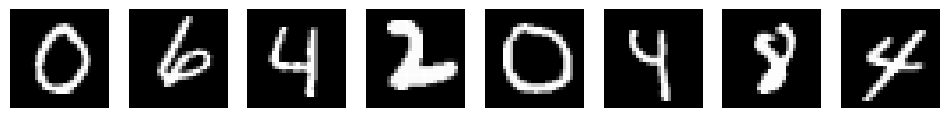

In [14]:
load_and_plot(num_samples=8)

### Preprocess the Dataset  

- Apply **binarization** to the images: Convert pixel values to either 0 or 1 based on a chosen threshold.  
- Convert the dataset to **float32** for compatibility with the model.  
- Reshape the dataset to include a **single channel** for grayscale images.  
- Print the **shapes** of the training and testing datasets to verify the preprocessing steps.  


In [15]:
# your code here
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#Normalize
x_train = x_train / 255.0
x_test  = x_test / 255.0

# Binarize
threshold = 0.5
x_train = (x_train > threshold).astype(np.float32)
x_test  = (x_test  > threshold).astype(np.float32)

#adding channel dimension for grayscale
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

x_train = x_train.astype(np.float32)
x_test  = x_test.astype(np.float32)

print("x_train shape after preprocessing:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape after preprocessing:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape after preprocessing: (60000, 28, 28, 1)
y_train shape: (60000,)
x_test shape after preprocessing: (10000, 28, 28, 1)
y_test shape: (10000,)


### Implement `PixelConv` Class

1. **Initialize the Layer:**  
   - Define a convolutional layer with the given parameters.  
   - Store the mask type ('A' or 'B') as an instance variable.  

2. **Create a Mask in the `setup_layer` Method:**  
   - Generate a mask matrix that ensures autoregressive pixel dependencies.  
   - Implement different masking rules for **Mask Type A and Mask Type B**.  

3. **Apply the Mask in the `apply_mask` Method:**  
   - Multiply the convolution kernel with the mask before computing outputs.  
   - Ensure the layer respects the masked constraints during forward pass.  


In [16]:
class PixelConv(tf.keras.layers.Layer):
    def __init__(self, mask_type, filters, kernel_size=3, **kwargs):
        """
        mask_type: 'A' or 'B'
          - 'A' blocks the center pixel as well
          - 'B' allows the current pixel but blocks "future" pixels.
        filters: number of output filters for the convolution.
        kernel_size: size of the convolution kernel (e.g., 3).
        **kwargs: additional Conv2D layer arguments (e.g., activation, strides, etc.)
        """
        super().__init__()
        self.mask_type = mask_type
        self.filters = filters
        self.kernel_size = kernel_size

        self.conv = tf.keras.layers.Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            **kwargs
        )

    def build(self, input_shape):
        """
        Keras build phase. Create and store the mask here
        so that Keras knows about it in the same graph scope.
        """
        super().build(input_shape)

        self.conv.build(input_shape)

        kernel_shape = self.conv.kernel.shape
        mask_np = np.ones(kernel_shape, dtype=np.float32)

        center_h = self.kernel_size // 2
        center_w = self.kernel_size // 2

        if self.mask_type == 'A':
            mask_np[center_h, center_w, :, :] = 0.0

        mask_np[center_h, center_w+1:, :, :] = 0.0
        mask_np[center_h+1:, :, :, :] = 0.0

        self.mask = self.add_weight(
            name='mask',
            shape=kernel_shape,
            initializer=tf.constant_initializer(mask_np),
            trainable=False
        )

    def call(self, inputs):
        """
        Forward pass:
          1) Multiply the learned kernel by the mask
          2) Perform tf.nn.conv2d
          3) Add bias if needed
        """
        masked_kernel = self.conv.kernel * self.mask

        outputs = tf.nn.conv2d(
            inputs,
            masked_kernel,
            strides=self.conv.strides,
            padding='SAME'
        )
        if self.conv.use_bias:
            outputs = tf.nn.bias_add(outputs, self.conv.bias)

        return outputs

### Implement a Residual Block for PixelCNN

A residual block helps improve training stability and allows better gradient flow by adding shortcut connections. In this class, you will define a residual block using convolutional layers and a masked convolution.

### Steps to Implement:

1. **Initialize the Layers**  
   - Define convolutional layers and a masked convolutional layer.  
   - Ensure the masked convolution follows the correct masking strategy.  

2. **Forward Pass**  
   - Pass the input through the layers sequentially.  
   - Implement the residual connection by combining the input and output.  

In [17]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, filters, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters

        self.conv1 = layers.Conv2D(
            filters=self.filters,
            kernel_size=1,
            padding='same',
            activation='relu'
        )
        self.masked_conv = PixelConv(
            mask_type='B',
            filters=self.filters,
            kernel_size=3,
            activation='relu'
        )
        self.conv2 = layers.Conv2D(
            filters=self.filters,
            kernel_size=1,
            padding='same'
        )

    def call(self, inputs):
        """
        Standard residual block forward pass:
          conv1 -> relu
          masked_conv -> relu
          conv2
          + skip connection
        """
        x = self.conv1(inputs)
        x = self.masked_conv(x)
        x = self.conv2(x)
        return x + inputs

### Putting it Together

Now you will build a PixelCNN model using masked convolutions and residual blocks to model pixel dependencies.

### To-Do:
1. **Define the input layer** for grayscale images.  
2. **Add an initial masked convolution** to process input features.  
3. **Stack multiple residual blocks** to refine the learned representations.  
4. **Include additional masked convolutions** to further process the data.  
5. **Create an output layer** that predicts pixel values.  
6. **Ensure the total parameter count remains within 600,000.**  
7. **Display a summary** of your model and verify its structure and parameters.

In [18]:
def build_pixelcnn(input_shape=(28,28,1),
                   num_residual_blocks=5,
                   filters=64):
    """
    Builds a PixelCNN model with:
      - An initial Mask A convolution
      - Several ResidualBlocks (with Mask B)
      - Additional Mask B conv
      - Final 1x1 conv => logits

    Returns:
      A tf.keras.Model
    """

    inputs = layers.Input(shape=input_shape)

    x = PixelConv(
        mask_type='A',
        filters=filters,
        kernel_size=7,
        padding='same'
    )(inputs)

    for _ in range(num_residual_blocks):
        x = ResidualBlock(filters)(x)

    x = PixelConv(
        mask_type='B',
        filters=filters,
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)
    x = PixelConv(
        mask_type='B',
        filters=filters,
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)

    x = layers.Conv2D(
        filters=1,
        kernel_size=1,
        padding='same'
    )(x)

    model = Model(inputs, x, name="PixelCNN")
    model.summary()
    return model


model = build_pixelcnn(input_shape=(28,28,1), num_residual_blocks=5, filters=64)

Model: "PixelCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_16 (PixelConv)            │ (None, 28, 28, 64)          │           6,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_10 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_11 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_12 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_13 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_14 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_22 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_23 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_56 (Conv2D)                   │ (None, 28, 28, 1)           │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 564,545 (2.15 MB)

 Trainable params: 303,361 (1.16 MB)

 Non-trainable params: 261,184 (1020.25 KB)

### Train your PixelCNN
You will now train the PixelCNN model and visualize its performance.

### To-Do:
1. **Compile the model** with an appropriate optimizer and loss function.  
2. **Train the model** for three different epoch settings: **10, 20, and 30**.  
3. **Plot the training and validation loss** for all three variations to analyze model performance over epochs.

In [19]:

def train_pixelcnn(x_train, x_test, epochs=10, filters=64, blocks=5):
    """
    Builds, compiles, and trains a PixelCNN model for a given number of epochs.
    Returns (model, history).
    """
    model = build_pixelcnn(
        input_shape=(28,28,1),
        num_residual_blocks=blocks,
        filters=filters
    )

    #compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True)
    )

    #train
    history = model.fit(
        x=x_train, y=x_train,
        validation_data=(x_test, x_test),
        batch_size=64,
        epochs=epochs,
        verbose=1
    )
    return model, history

model_dict = {}
history_dict = {}
epochs_list = [10, 20, 30]

for ep in epochs_list:
    print(f"\n=== Training fresh model for {ep} epochs ===")
    temp_model, temp_history = train_pixelcnn(
        x_train, x_test,
        epochs=ep,
        filters=64,
        blocks=5
    )
    model_dict[ep] = temp_model
    history_dict[ep] = temp_history


=== Training fresh model for 10 epochs ===


Model: "PixelCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_24 (PixelConv)            │ (None, 28, 28, 64)          │           6,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_15 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_16 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_17 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_18 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_19 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_30 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_31 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_75 (Conv2D)                   │ (None, 28, 28, 1)           │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 564,545 (2.15 MB)

 Trainable params: 303,361 (1.16 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_40 (PixelConv)            │ (None, 28, 28, 64)          │           6,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_25 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_26 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_27 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_28 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ residual_block_29 (ResidualBlock)    │ (None, 28, 28, 64)          │          82,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_46 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_conv_47 (PixelConv)            │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_113 (Conv2D)                  │ (None, 28, 28, 1)           │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 564,545 (2.15 MB)

 Trainable params: 303,361 (1.16 MB)

 Non-trainable params: 261,184 (1020.25 KB)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - loss: 0.1252 - val_loss: 0.0879
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - loss: 0.0879 - val_loss: 0.0858
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - loss: 0.0861 - val_loss: 0.0860
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - loss: 0.0853 - val_loss: 0.0848
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - loss: 0.0848 - val_loss: 0.0845
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - loss: 0.0842 - val_loss: 0.0844
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 0.0841 - val_loss: 0.0837
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 0.0836 - val_loss: 0.0837
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - loss: 0.0835 - val_loss: 0.0834
Epoch 10/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 0.0833 - val_loss: 0.0833
Epoch 11/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - loss: 0.0832 - val_loss: 0.0835
Epoch 12/30
938/938 ━━━━━━━━━━

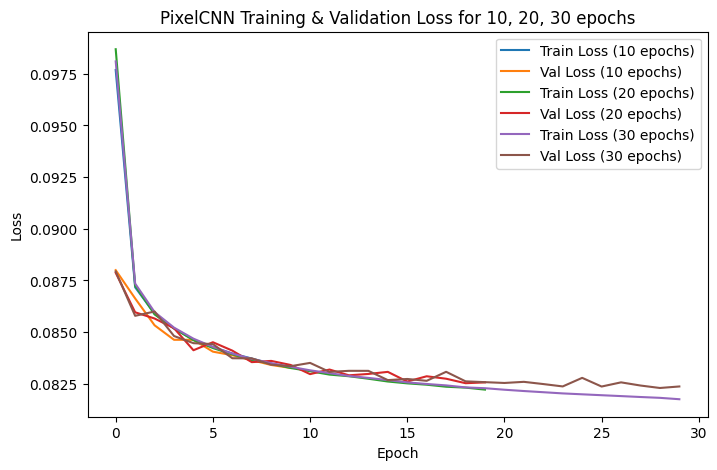

In [20]:
plt.figure(figsize=(8,5))
for ep in epochs_list:
    h = history_dict[ep]
    plt.plot(h.history['loss'], label=f"Train Loss ({ep} epochs)")
    plt.plot(h.history['val_loss'], label=f"Val Loss ({ep} epochs)")

plt.title("PixelCNN Training & Validation Loss for 10, 20, 30 epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

You will generate images pixel by pixel using three different trained PixelCNN models:  
- Model trained for **10 epochs**  
- Model trained for **20 epochs**  
- Model trained for **30 epochs**  

Each model will sequentially predict pixel values to generate new images.  

### To-Do:  
1. **Set up the necessary structure** for image generation.  
2. **Leverage the trained model** to infer missing pixel values step by step.  
3. **Determine pixel values** based on predictions.  
4. **Run the process with different models** and observe the outcomes.  
5. **Compare the generated images** to analyze any differences.


Generating images with the 10-epoch model...


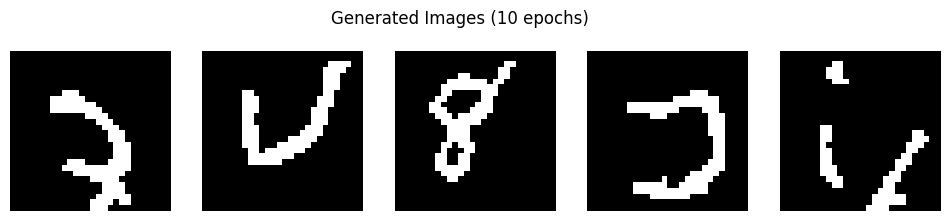


Generating images with the 20-epoch model...


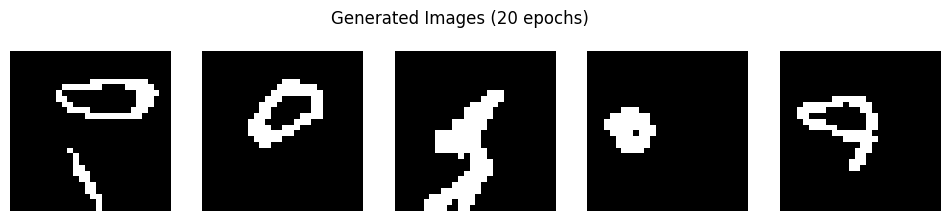


Generating images with the 30-epoch model...


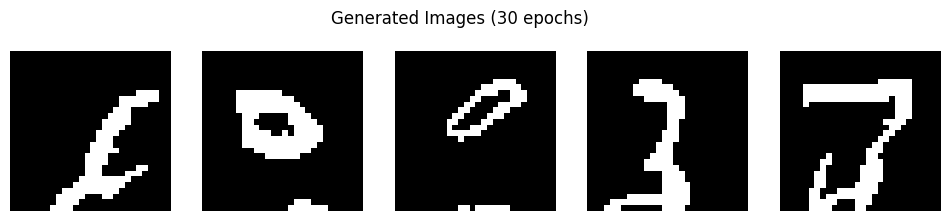

In [27]:
# your code here
def generate_images_pixel_by_pixel(model, num_samples=5):
    """
    Generates num_samples images (28x28) using the given PixelCNN model.
    Fills each pixel by scanning left-to-right, top-to-bottom.

    Returns:
      A NumPy array of shape (num_samples, 28, 28).
    """
    gen_images = np.zeros((num_samples, 28, 28, 1), dtype=np.float32)

    for row in range(28):
        for col in range(28):
            logits = model.predict(gen_images, verbose=0)

            pixel_logit = logits[:, row, col, 0]
            pixel_prob  = tf.nn.sigmoid(pixel_logit)

            sampled_pixel = tf.cast(
                tf.random.uniform(shape=pixel_prob.shape) < pixel_prob,
                tf.float32
            )

            gen_images[:, row, col, 0] = sampled_pixel.numpy()

    return gen_images[..., 0]

def plot_generated_images(images, title="Generated Images", num_show=5):
    """
    Utility to plot a small batch of generated images in a row.
    images should be a NumPy array of shape (num_images, 28, 28).
    """
    plt.figure(figsize=(12, 2.5))
    for i in range(num_show):
        plt.subplot(1, num_show, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


num_samples = 5

for ep in epochs_list:
    print(f"\nGenerating images with the {ep}-epoch model...")

    model = model_dict[ep]
    images = generate_images_pixel_by_pixel(model, num_samples=num_samples)

    plot_generated_images(images, title=f"Generated Images ({ep} epochs)")

## Reflection Questions  

After completing this part, take some time to reflect on the following questions:    


1. **How do the generated images differ across models trained for 10, 20, and 30 epochs?** What patterns or improvements do you notice with more training?



Answer:at 10 epochs,the images are rough and noisy, with disconnected or incomplete digit strokes. It's difficult to confidently recognize many digits, indicating the model hasn't yet learned a strong distribution over MNIST digits.At 20 epochs,the shapes start to become more structured. Some digits like 0 and 9 become more recognizable, although inconsistencies are still present.at 30 epochs its more or less like 20 epochs but with less noise and it seems the strokes are more defined.With more training, the model produces more realistic and higher quality digits due to improved estimation of the pixel dependencies inimages.

2. **What role does the masked convolution play in PixelCNN?** How does it influence the way images are generated?

Answer:masked convulation is necessary in pixel cnn  meaning each pixel is generated only based on previously generated pixels.mask A is used in the first layer to completely block access to the current pixel, ensuring the model doesn’t cheat during generation.mask B is used in deeper layers to allow the current pixel but still block future pixels.This masking ensures that during both training and generation, the model follows to a consistent pixel by pixel generation order. It prevents the model from accessing future  pixels and allows it to model the conditional distribution of each pixel given the previous ones. This is what makes pixelcnn a valid generative model for images.

<h1><b><span style="color: #9370DB;"> Part 1 Done!</span></h1>